## Company : All Soft - IBM 

### Name : Dhwani Gupta                                                                                                                       
### Roll no. : 07690202021 
### College : Sri Guru Tegh Bahadur Institute of Management and Information Technology 
### Topic : Heart disease prediction

## Here we are importing pandas library as pd and we would perform different functions of pandas using pd on our dataframe.

In [1]:
!pip install scikit-learn==1.3.2 --quiet
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.3.2


In [2]:
import pandas as pd

### This command is used to ignore the printing of warning.

In [3]:
import warnings
warnings.filterwarnings('ignore')

### * Here we are reading our dataframe (format .csv) with the help of variable "df" *

In [4]:
df=pd.read_csv("heartDisease.csv")

In [5]:
df # printing our data frame 

,Unnamed: 0,age,Gender,Country,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result
0,0,63,Male,Cleveland,1,145,233,1,1,150,0,2,3,0,1,0
1,2,67,Male,Cleveland,2,120,229,0,1,129,1,2,2,2,3,1
2,3,37,Male,Cleveland,3,130,250,0,2,187,0,3,3,0,2,0
3,4,41,Female,Cleveland,4,130,204,0,1,172,0,1,1,0,2,0
4,5,56,Male,Cleveland,4,120,236,0,2,178,0,0,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,268,68,Male,Switzerland,2,144,193,1,2,141,0,3,2,2,3,2
232,269,57,Male,Switzerland,2,130,131,0,2,115,1,1,2,1,3,3
233,270,57,Female,Switzerland,4,130,236,0,1,174,0,0,2,1,2,1
234,271,38,Male,Switzerland,3,138,175,0,2,173,0,0,1,0,2,0


# A. Preproccesing & Data Cleaning

###### Data preprocessing  & Data cleaning
Data preprocessing is a step in the data mining and data analysis process that takes raw data and transforms it into a format 
that can be understood and analyzed by computers and machine learning.

Data cleaning is the process of adding missing data and correcting, repairing, or removing incorrect or irrelevant data from a data set

## A.1 Checking the "Null" values present in our data frame.

By using isnull() function we can check whether there is any null value present in our data set or not.

In [6]:
df.isnull().sum() 

Unnamed: 0    0
age           0
Gender        0
Country       0
chest pain    0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
Result        0
dtype: int64

### A.1.1 Droping null values of different columns 

Dropna() function always work on a data frame rather than on a particular column, so if we want to appyly it on a particular column we can use keyword "subset" as an arrgument for that.

In [7]:
df.dropna(subset=["thalch"],inplace=True)

In [8]:
df.dropna(subset=["exang"],inplace=True)

In [9]:
df.dropna(subset=["trestbps"],inplace=True)

### A.1.2 Filling null values of different columns.

In this section we are filling the null values by using fillna() function,  either by finding the mean of that particular column with the help of mean() function or filling the value which is occurring maximum time by using the mode() function.

fillna() - fill the value where the values are null in the database.                                                             
mean() - find mean of that column.                                                                                               
mode() - find mode of that column.

###### oldpeak column

In [10]:
df["oldpeak"]=df["oldpeak"].fillna(df["oldpeak"].mean())

###### slope column

In [11]:
df["slope"].value_counts()

slope
1    115
2    105
3     16
Name: count, dtype: int64

In [12]:
df["slope"]=df["slope"].fillna(df["slope"].mode()[0])

In [13]:
df["slope"].value_counts()

slope
1    115
2    105
3     16
Name: count, dtype: int64

###### fbs column

In [14]:
df["fbs"].value_counts()

fbs
0    203
1     33
Name: count, dtype: int64

In [15]:
df["fbs"]=df["fbs"].fillna(df["fbs"].mode()[0])

In [16]:
df["fbs"].value_counts()

fbs
0    203
1     33
Name: count, dtype: int64

###### ca column

In [17]:
df["ca"].unique()

array([0, 2, 1], dtype=int64)

In [18]:
df["ca"].value_counts()

ca
0    152
1     56
2     28
Name: count, dtype: int64

In [19]:
df["ca"]=df["ca"].fillna(df["ca"].mean())
df["ca"]=df["ca"].astype(int)

In [20]:
df["ca"].value_counts()

ca
0    152
1     56
2     28
Name: count, dtype: int64

###### thal column

In [21]:
df["thal"].value_counts()

thal
2    135
3     87
1     14
Name: count, dtype: int64

In [22]:
df["thal"]=df["thal"].fillna(df["thal"].mode()[0])

In [23]:
df["thal"].value_counts()

thal
2    135
3     87
1     14
Name: count, dtype: int64

## A.2 No Null values present in our dataframe
sum() function return the total of that with which it is used.

In [24]:
df.isnull().sum()

Unnamed: 0    0
age           0
Gender        0
Country       0
chest pain    0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
Result        0
dtype: int64

### A.3 Checking duplicate value 
It tells the duplicasy of data. By using duplicated() function we can see the number of rows having exact same value or we can say that 1 row is copy of another & 
sum() function return the total of that with which it is used.

In [25]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
231    False
232    False
233    False
234    False
235    False
Length: 236, dtype: bool

In [26]:
df.duplicated().sum()

0

### A.4 Replacing String value to Numerical Value of different columns
Replacing the string values into numeric value so that computer can read and understand that particular value, moreover each different value of a column gets a unique number.

unique() - return the number of unique value present in that particular column.                                                 
replace() - replace the string into numeric value.                                                                     
value_counts() - used to count the number of occurrence of unique value.

###### Column = slope

In [27]:
df["slope"].unique()

array([3, 2, 1], dtype=int64)

In [28]:
df["slope"]=df["slope"].replace({"upsloping":1,"flat":2,"downsloping":3})

In [29]:
df["slope"].value_counts()

slope
1    115
2    105
3     16
Name: count, dtype: int64

###### Column = thal

In [30]:
df["thal"].unique()

array([1, 3, 2], dtype=int64)

In [31]:
df["thal"]=df["thal"].replace({"fixed defect":1,"normal":2,"reversable defect":3})
df["thal"]=df["thal"].astype(int)

In [32]:
df["thal"].value_counts()

thal
2    135
3     87
1     14
Name: count, dtype: int64

###### Column = chest pain

In [33]:
df["chest pain"].unique()

array([1, 2, 3, 4], dtype=int64)

In [34]:
df["chest pain"]=df["chest pain"].replace({"typical angina":1,"asymptomatic":2,"non-anginal":3,"atypical angina":4})

In [35]:
df["chest pain"].value_counts()

chest pain
2    104
3     66
4     45
1     21
Name: count, dtype: int64

###### Column = restecg

In [36]:
df["restecg"].unique()

array([1, 2, 3], dtype=int64)

In [37]:
df["restecg"]=df["restecg"].replace({"lv hypertrophy":1,"normal":2,"st-t abnormality":3})

In [38]:
df["restecg"].value_counts()

restecg
2    127
1    106
3      3
Name: count, dtype: int64

###### Column = fbs

In [39]:
df["fbs"].unique()

array([1, 0], dtype=int64)

In [40]:
df["fbs"]=df["fbs"].replace({"Yes":1,"No":0})

In [41]:
df["fbs"].value_counts()

fbs
0    203
1     33
Name: count, dtype: int64

###### Column = exang

In [42]:
df["exang"].unique()

array([0, 1], dtype=int64)

In [43]:
df["exang"]=df["exang"].replace({"Yes":1,"No":0})

In [44]:
df["exang"].value_counts()

exang
0    160
1     76
Name: count, dtype: int64

###### Column = thalch , thal

In [45]:
df["trestbps"]=df["trestbps"].astype(int)
df["thalch"]=df["thalch"].astype(int)


### A.5 Renaming Column Names

rename() - it rename the name of column by giving previous value and new value in double quotes, differenticating it by using colon(:).  
axis = 1 is used to tell the compiler that it is y axis which are columns and axis = 0 means x - axis which are rows.

In [46]:
df=df.rename({"num":"Result"},axis=1)
df=df.rename({"sex":"Gender"},axis=1)
df=df.rename({"dataset":"Country"},axis=1)

### A.6 Printing the data frame after cleaning it.

In [47]:
df 

,Unnamed: 0,age,Gender,Country,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result
0,0,63,Male,Cleveland,1,145,233,1,1,150,0,2,3,0,1,0
1,2,67,Male,Cleveland,2,120,229,0,1,129,1,2,2,2,3,1
2,3,37,Male,Cleveland,3,130,250,0,2,187,0,3,3,0,2,0
3,4,41,Female,Cleveland,4,130,204,0,1,172,0,1,1,0,2,0
4,5,56,Male,Cleveland,4,120,236,0,2,178,0,0,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,268,68,Male,Switzerland,2,144,193,1,2,141,0,3,2,2,3,2
232,269,57,Male,Switzerland,2,130,131,0,2,115,1,1,2,1,3,3
233,270,57,Female,Switzerland,4,130,236,0,1,174,0,0,2,1,2,1
234,271,38,Male,Switzerland,3,138,175,0,2,173,0,0,1,0,2,0


## B. DATA VISUALISATION

### Importing libraries for using them for ploting graphs

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

### B.1 Data Visulisation on particular columns

### B.1.1 COUNTPLOT 

##### AGE 

(76, 29)

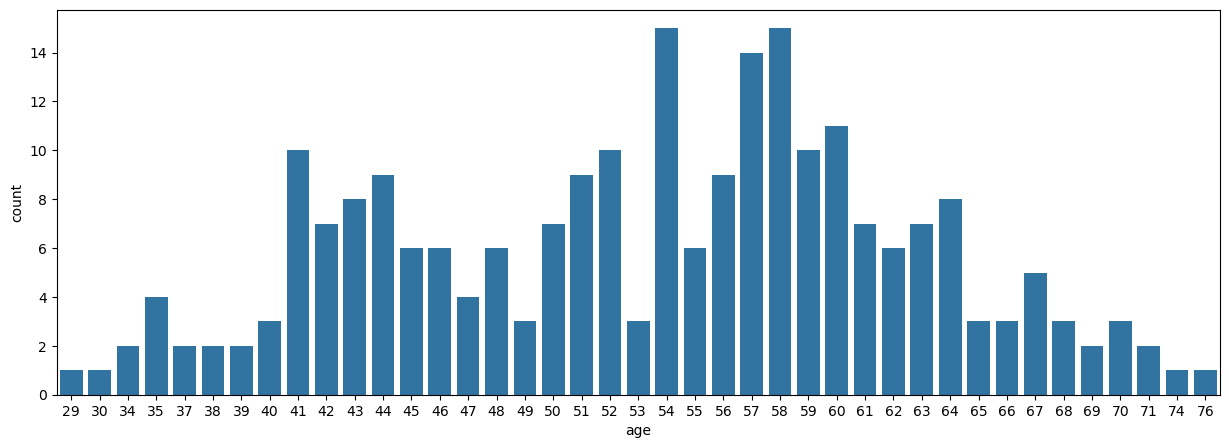

In [49]:
plt.figure(figsize=(15,5))
sns.countplot(x="age",data=df)
df["age"].max(),df["age"].min()

##### GENDER

<Axes: xlabel='Gender', ylabel='count'>

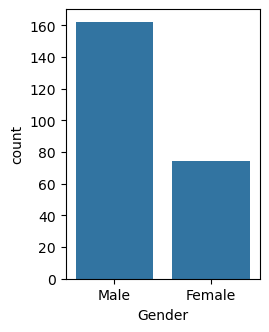

In [50]:
plt.figure(figsize=(2.5,3.5))
sns.countplot(x="Gender",data=df)

### B.1.2 PIE CHART 

#### Column - Gender

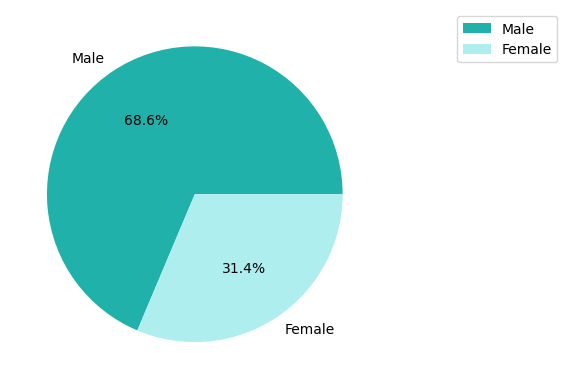

In [51]:
plt.pie(df["Gender"].value_counts(),autopct='%1.1f%%',labels=df['Gender'].unique(),colors = ["#20B2AA","#AFEEEE"])
plt.legend(df["Gender"].unique(),bbox_to_anchor=(1.5, 1),prop={'size': 10})

#### Column - Country

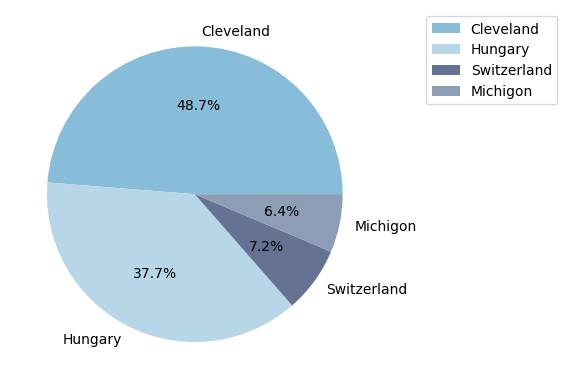

In [52]:
plt.pie(df["Country"].value_counts(),autopct='%1.1f%%',labels=df['Country'].unique(),colors = ["#87bdd8","#b7d7e8","#667292","#8d9db6"])
plt.legend(df["Country"].unique(),bbox_to_anchor=(1.5, 1),prop={'size': 10})

### B.1.3 Printing the boxplot and histogram of different columns simultaneously 

<Figure size 640x480 with 0 Axes>

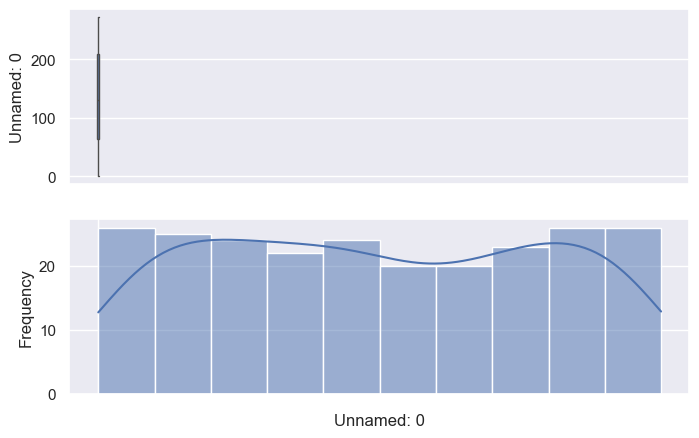

<Figure size 800x500 with 0 Axes>

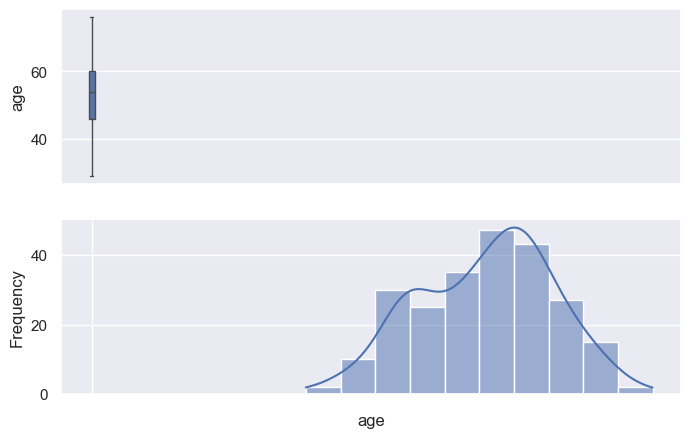

<Figure size 800x500 with 0 Axes>

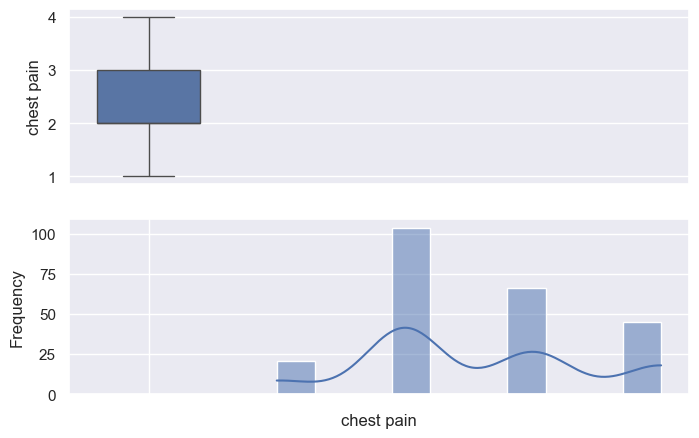

<Figure size 800x500 with 0 Axes>

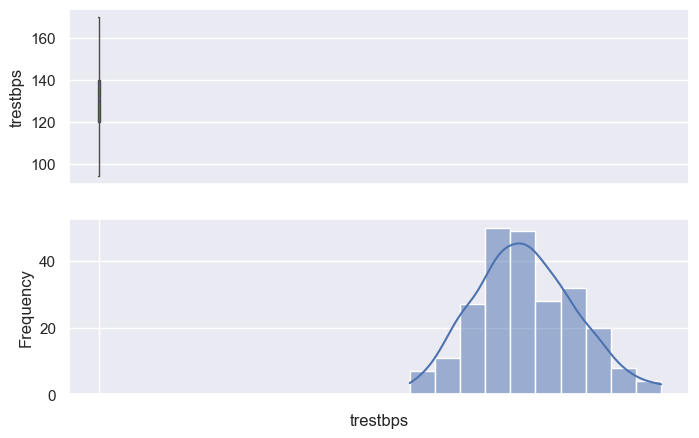

<Figure size 800x500 with 0 Axes>

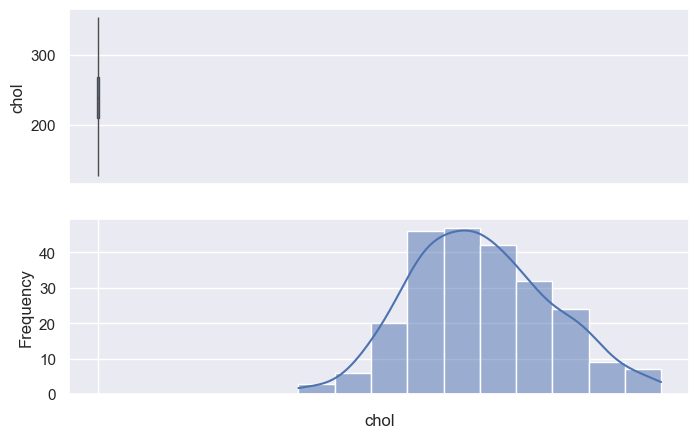

<Figure size 800x500 with 0 Axes>

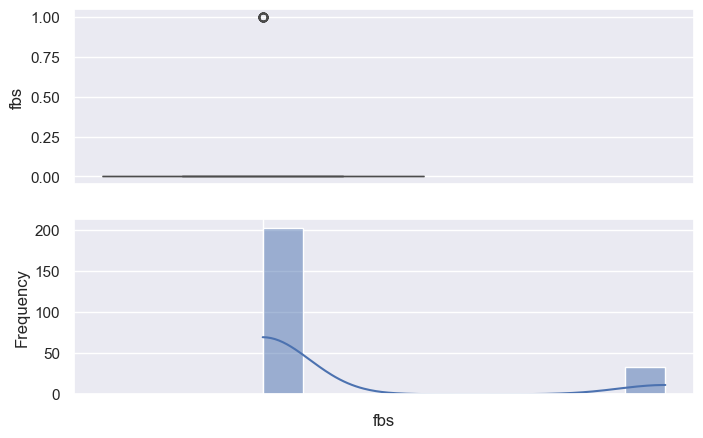

<Figure size 800x500 with 0 Axes>

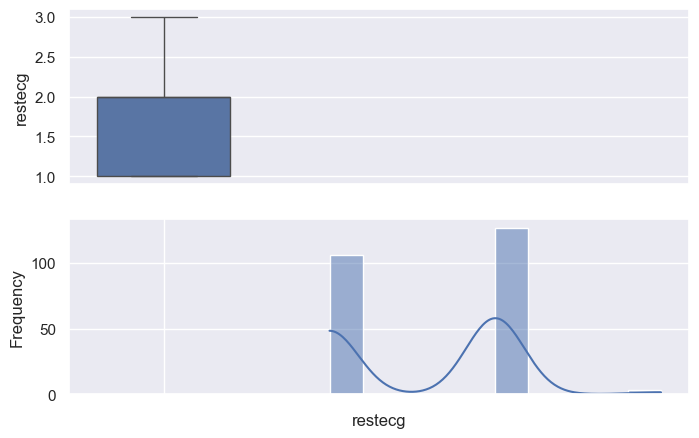

<Figure size 800x500 with 0 Axes>

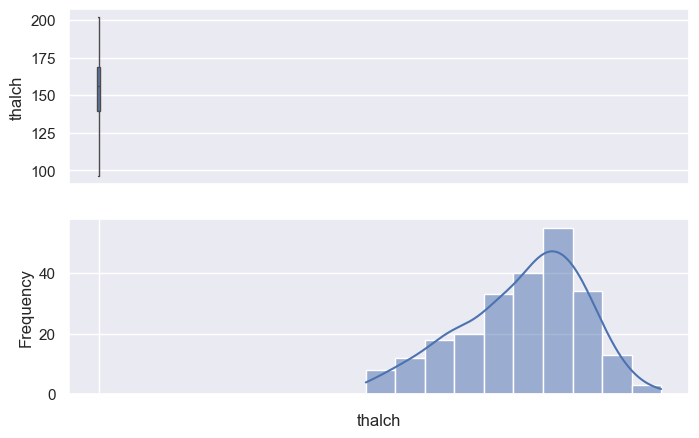

<Figure size 800x500 with 0 Axes>

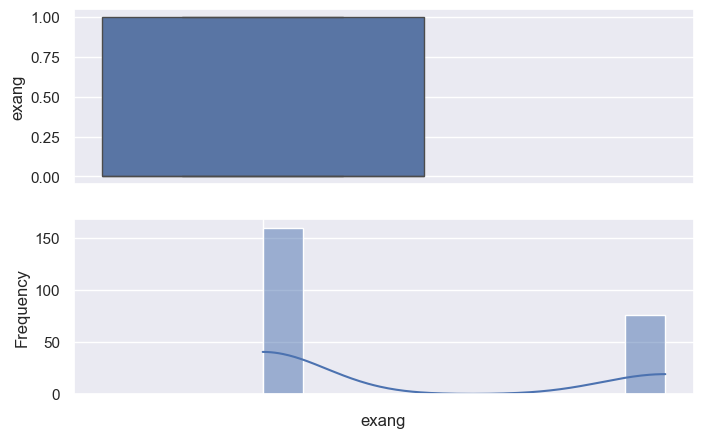

<Figure size 800x500 with 0 Axes>

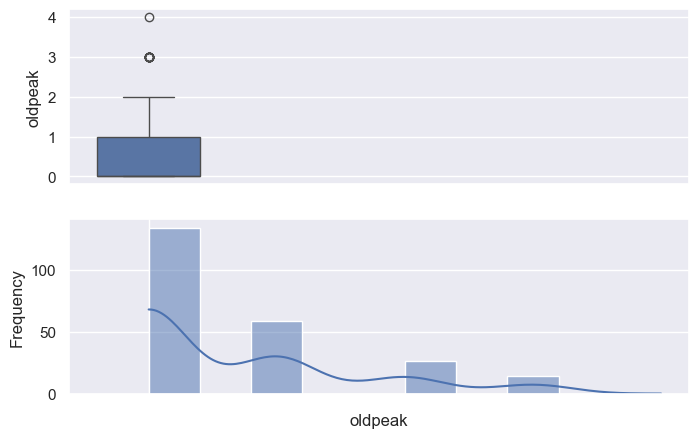

<Figure size 800x500 with 0 Axes>

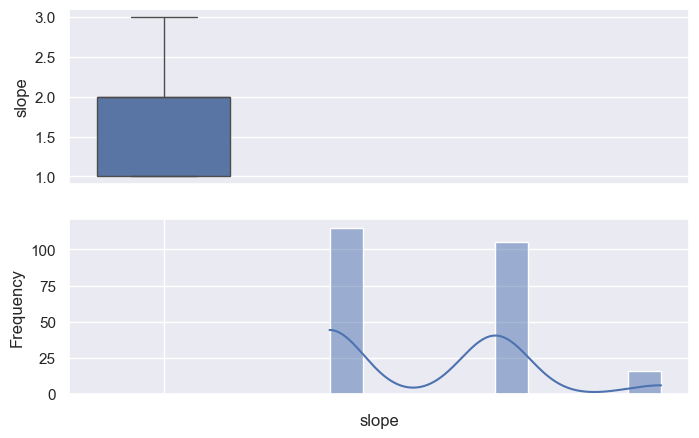

<Figure size 800x500 with 0 Axes>

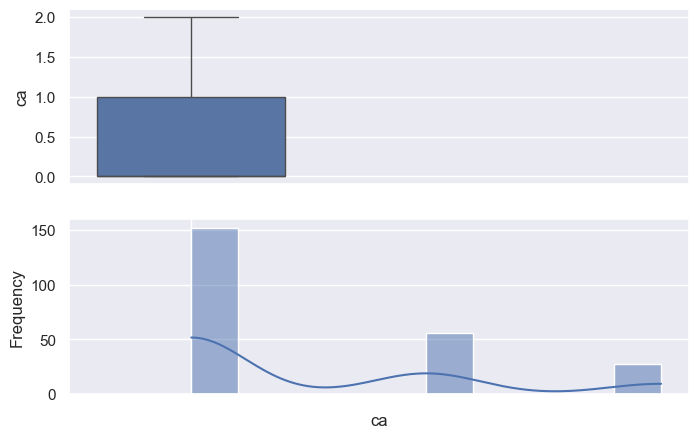

<Figure size 800x500 with 0 Axes>

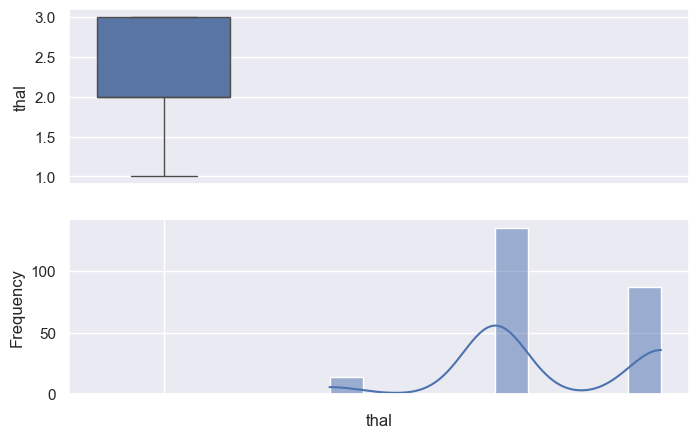

<Figure size 800x500 with 0 Axes>

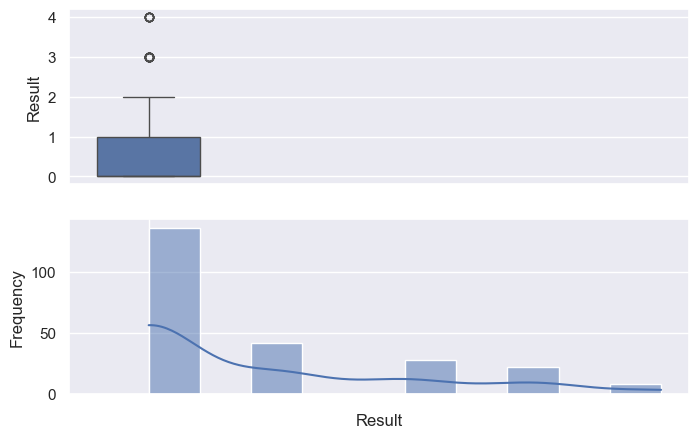

In [53]:
columns = list(df.select_dtypes('int'))
for i in columns:
    plt.figure()
    plt.tight_layout()
    sns.set(rc={"figure.figsize":(8, 5)})
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
    plt.gca().set(xlabel= i,ylabel='Frequency')
    sns.boxplot(df[i], ax=ax_box , linewidth= 1.0)
    sns.histplot(df[i], ax=ax_hist , bins = 10,kde=True)
    p=plt.show()

<Axes: xlabel='oldpeak', ylabel='Count'>

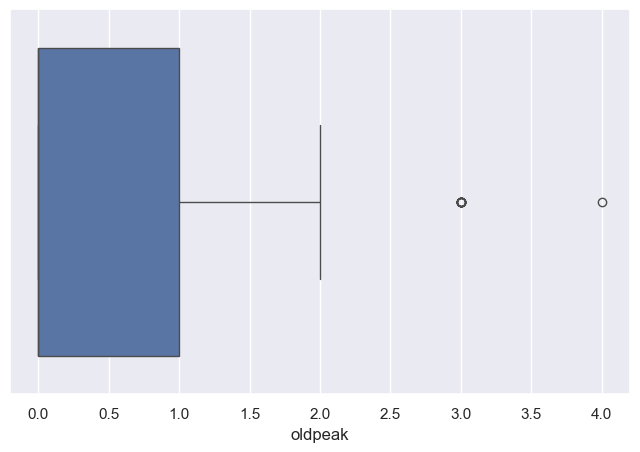

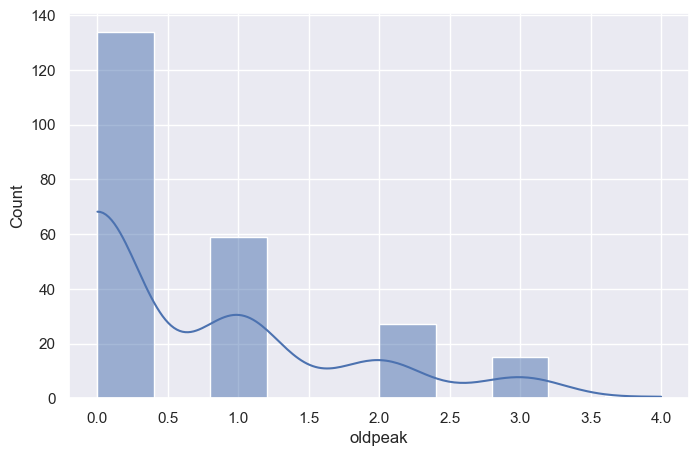

In [54]:
plt.subplots(1,1)
sns.boxplot(x="oldpeak",data=df, linewidth= 1.0)
plt.subplots(1,1)
sns.histplot(x="oldpeak",data=df,kde=True,bins=10)

### B.1.4 Printing the dependent column individually using countplot

<Axes: xlabel='Result', ylabel='count'>

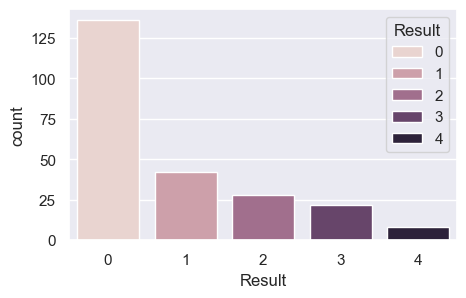

In [55]:
plt.figure(figsize=(5,3))
sns.countplot(x="Result",data=df,hue="Result")

### B.2 RELATIONS BETWEEN THE COLUMNS

### B.2.1 Relation between the Gender Column and the dependent Column = Result

<Axes: xlabel='Result', ylabel='count'>

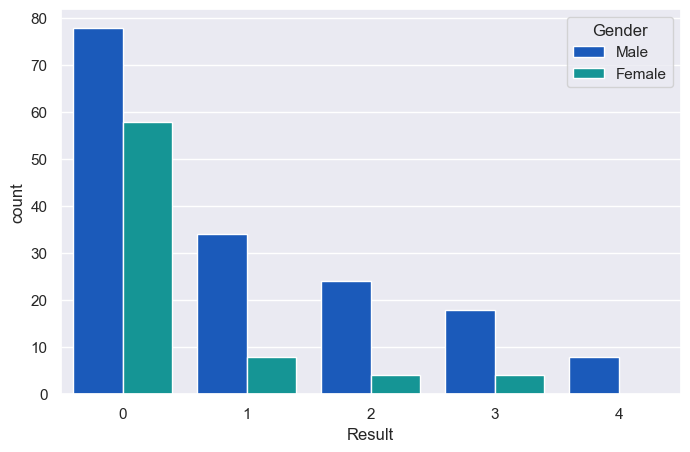

In [56]:
sns.countplot(x="Result",data=df,hue="Gender",palette="winter")

### B.2.2 Relation of Chest pain Column with the Result Column

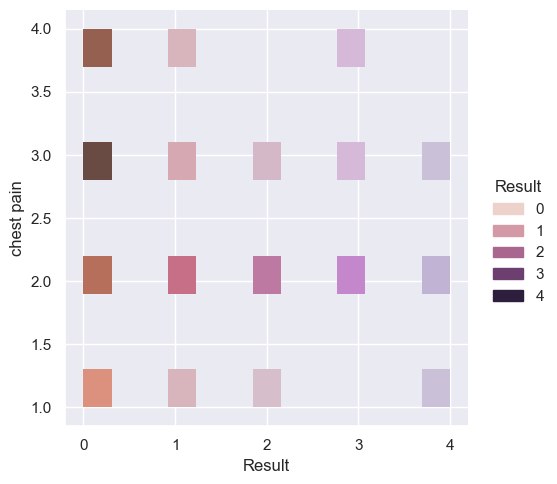

In [57]:
sns.displot(x="Result",y="chest pain",data=df,hue="Result")

### B.2.3 Relation between the independent columns and dependent column 

### Bar Graph

In [58]:
brlist=["Gender","Country","chest pain","fbs","restecg","exang","slope","ca","thal"]

####  ploting the graphs between Result column and Other columns

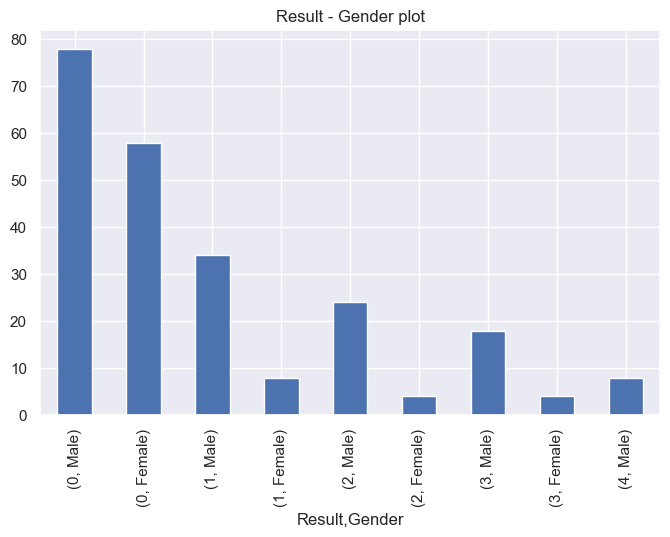

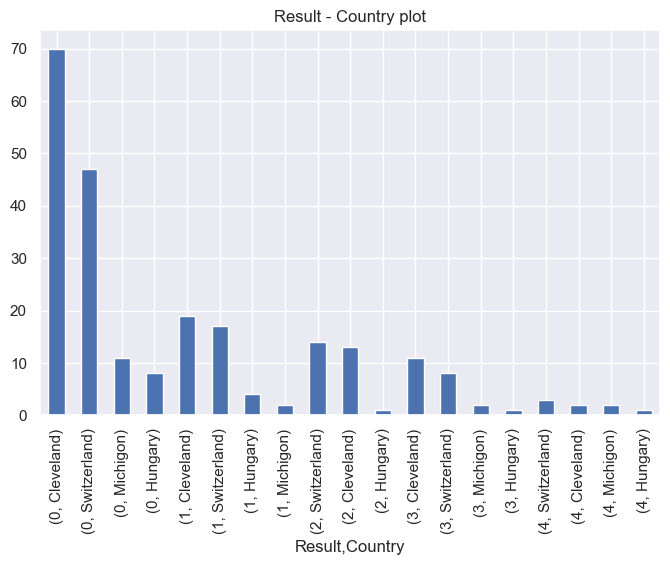

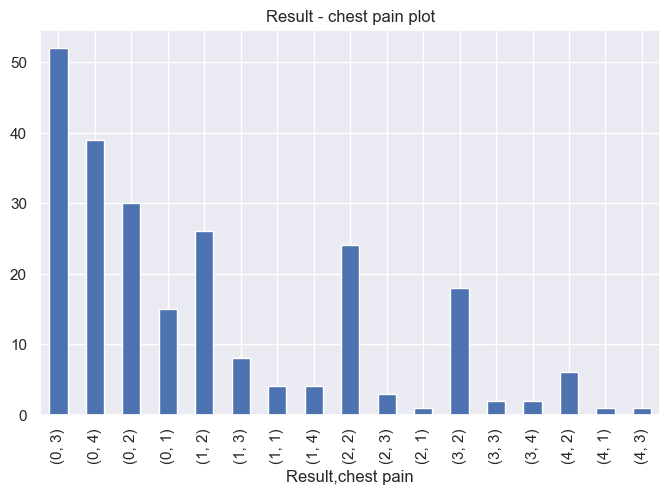

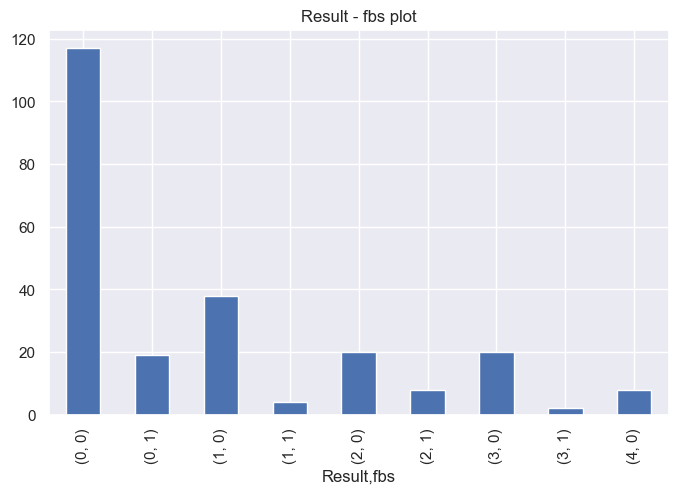

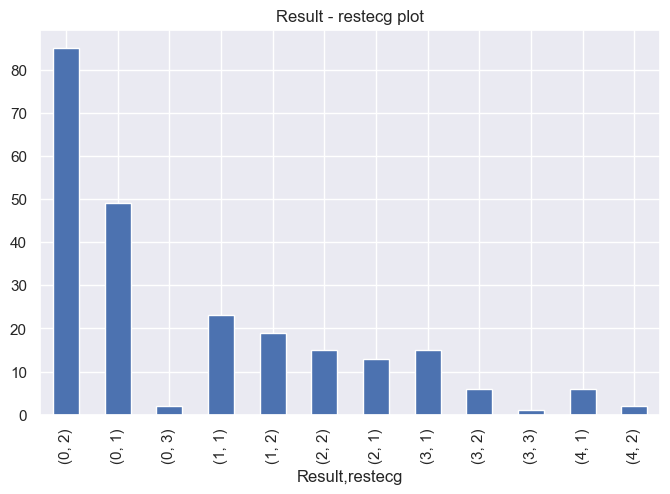

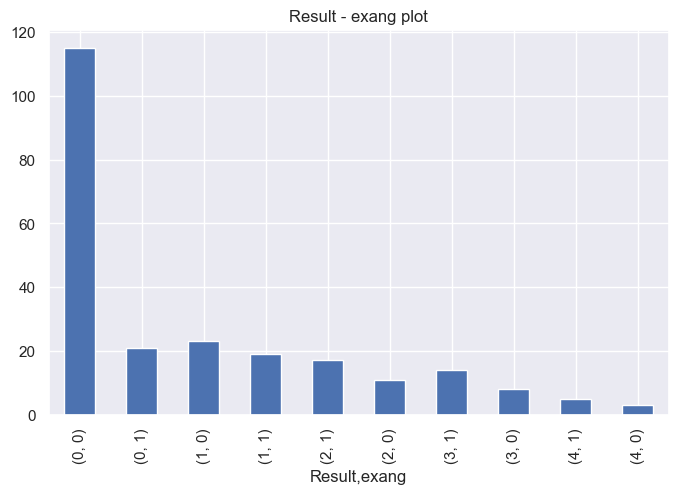

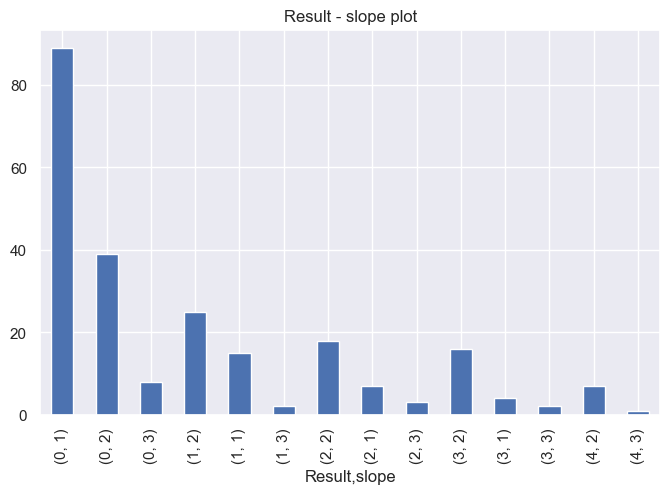

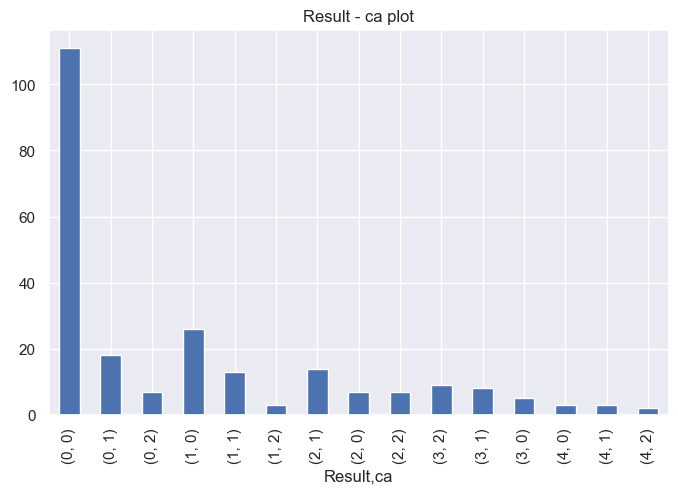

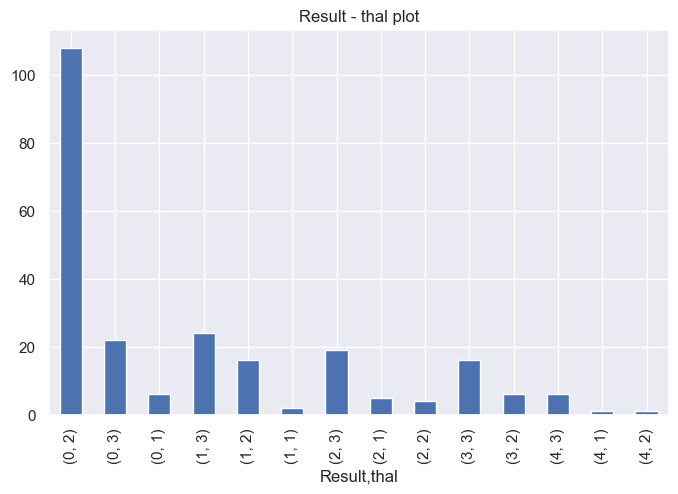

In [59]:
for i in brlist:
    hd=df.groupby("Result")[i].value_counts()
    hd.plot(kind="bar")
    plt.title(f"Result - {i} plot")
    plt.show()

### Scatter Plot

####  ploting the graphs of relation between the different columns of the dataset

In [60]:
sclist1=["chol","thalch","oldpeak"]

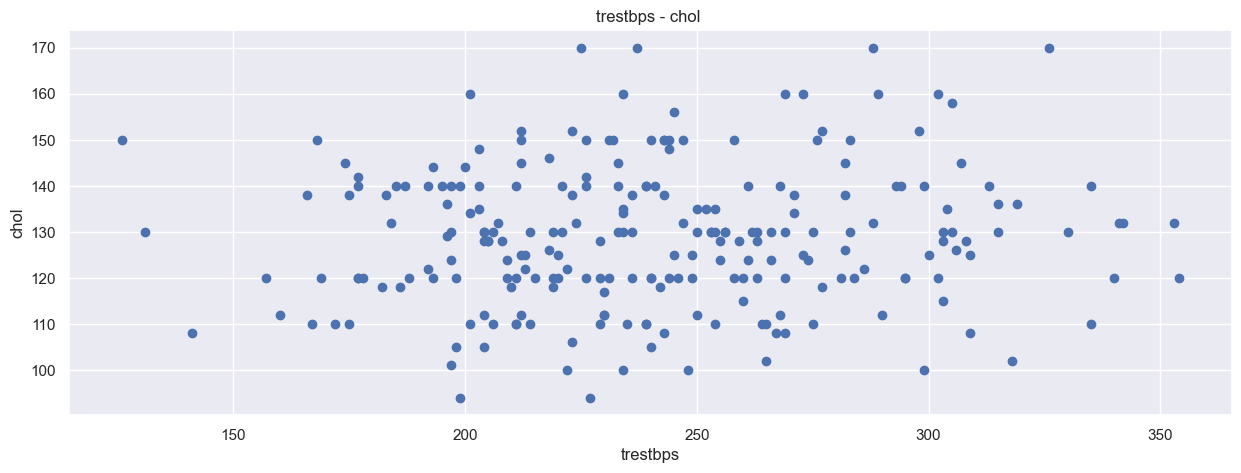

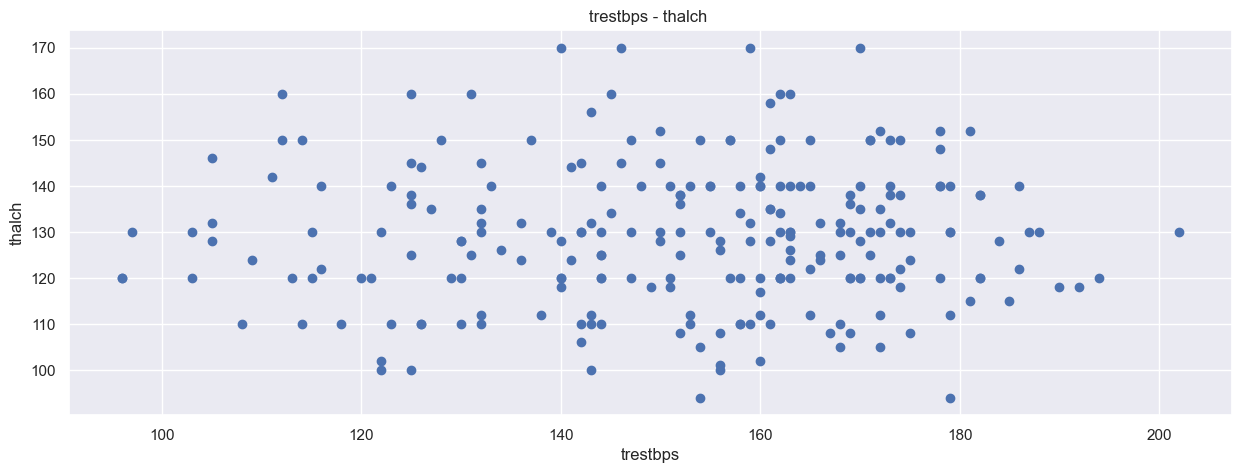

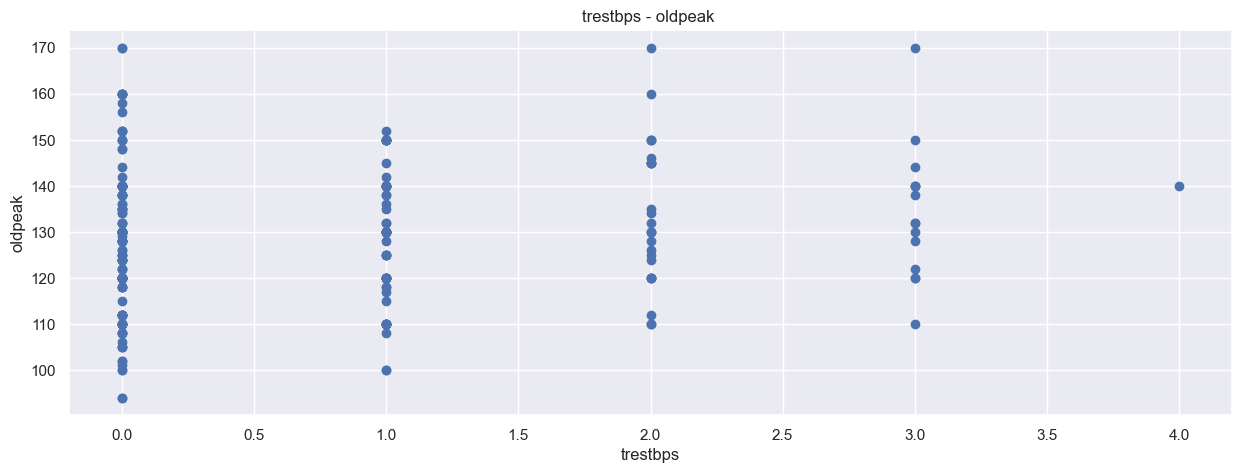

In [61]:
for i in sclist1:
    plt.figure(figsize=(15,5))
    plt.scatter(df[i],df["trestbps"])
    plt.title(f"trestbps - {i} ")
    plt.xlabel("trestbps")
    plt.ylabel(i)
    plt.show()

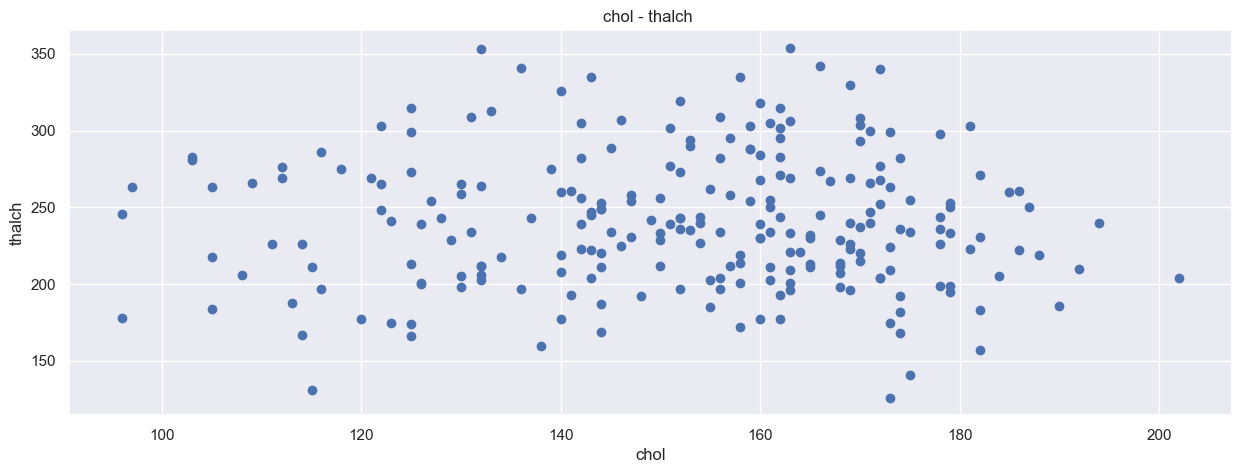

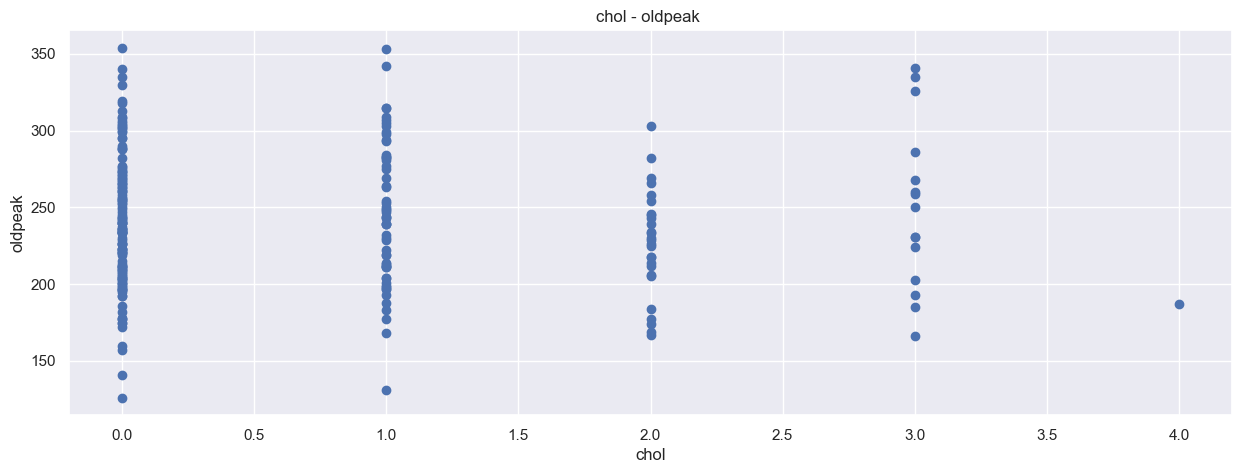

In [62]:
sclist1=["thalch","oldpeak"]
for i in sclist1:
    plt.figure(figsize=(15,5))
    plt.scatter(df[i],df["chol"])
    plt.title(f"chol - {i} ")
    plt.xlabel("chol")
    plt.ylabel(i)
    plt.show()

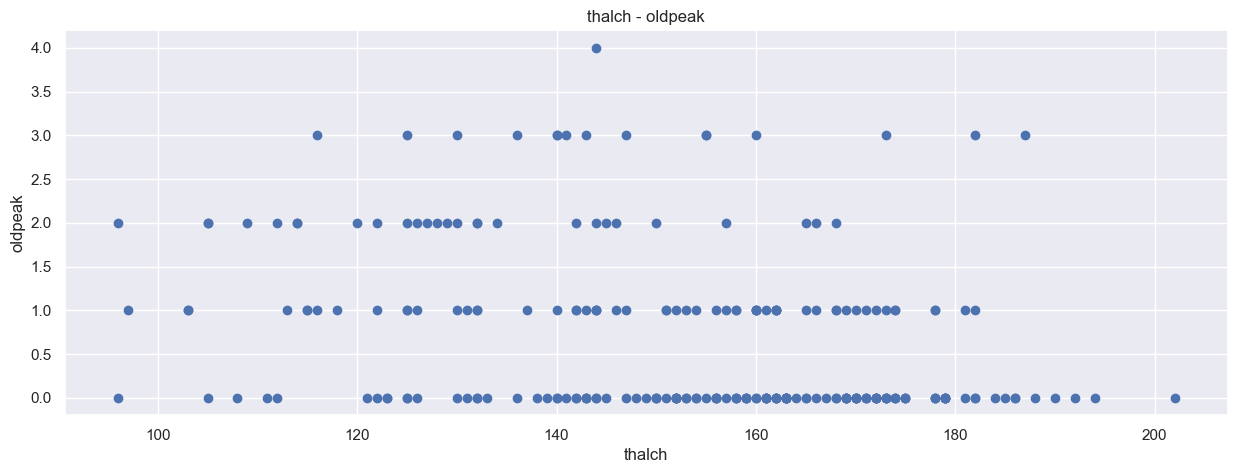

In [63]:
plt.figure(figsize=(15,5))
plt.scatter(df["thalch"],df["oldpeak"])
plt.title(f"thalch - oldpeak")
plt.xlabel("thalch")
plt.ylabel("oldpeak")
plt.show()

###  HEAT MAP
### Correlation Between the columns of the data set

plt.figure(figsize=(10,10))
plt.title('Correlation Between The Features')
a = sns.heatmap(df.corr(), annot=True, fmt='.2f', linewidths=2.5)
a.set_xticklabels(a.get_xticklabels(), rotation=35)
a.set_yticklabels(a.get_yticklabels())
plt.show()

### Box Plot 
It shows the outliers of different columns and center tendancy of the values of that column.

(-5.0, 425.0)

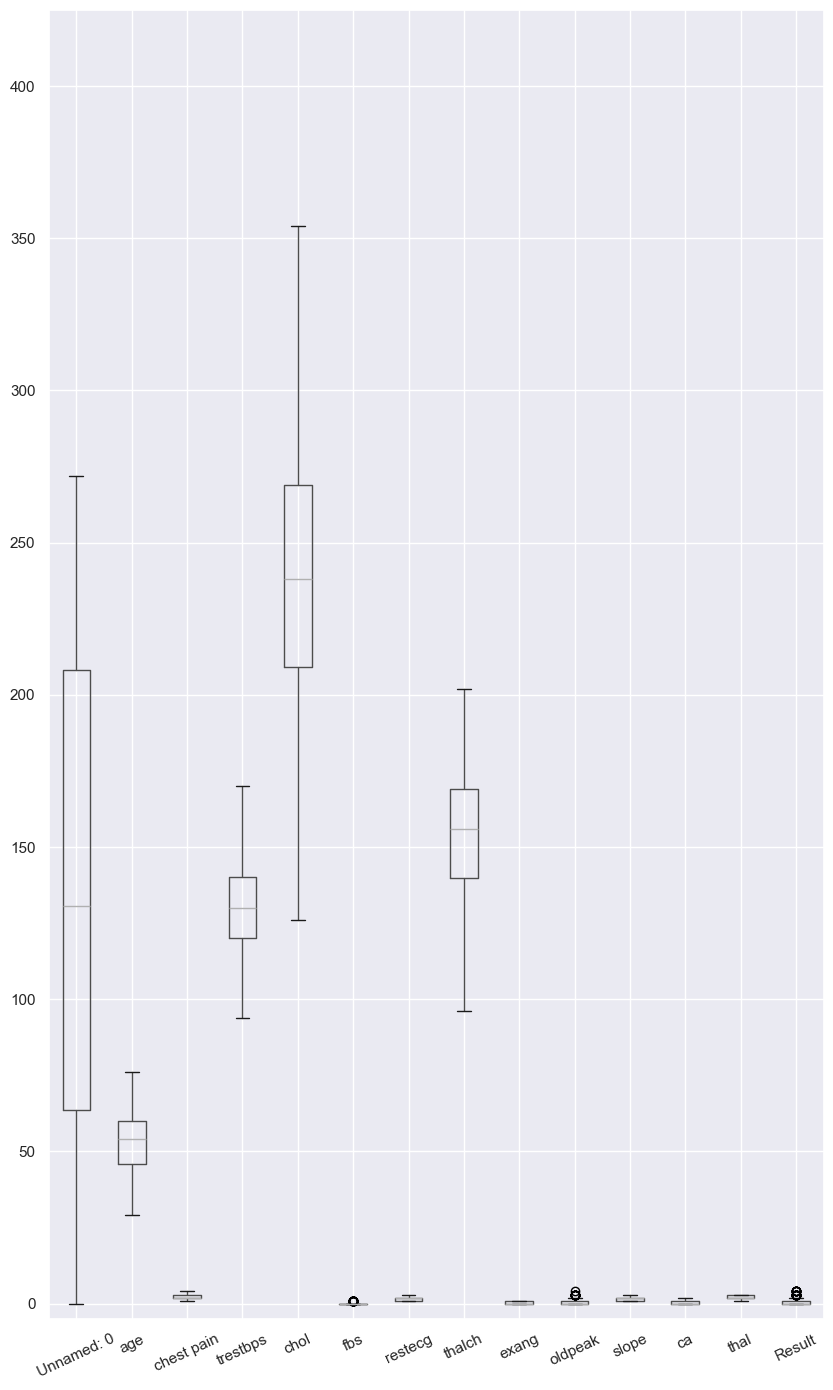

In [65]:
plt.figure(figsize=(10,17))
df.boxplot(rot=25)
plt.ylim(-5,425)

## OUTLIERS
An outlier is an extremely high or extremely low data point relative to the nearest data point and the rest of the neighboring co-existing values in a data graph or dataset.

#### descrie() is used to describe the statistics of numeric column of the data frame.

In [66]:
df.describe()

,Unnamed: 0,age,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result
count,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000
mean,135.245763,53.398305,2.572034,128.919492,240.838983,0.139831,1.563559,152.139831,0.322034,0.686441,1.580508,0.474576,2.309322,0.830508
std,81.295357,9.156456,0.898641,15.254922,43.938055,0.347548,0.522052,21.764150,0.468249,0.938075,0.617029,0.699080,0.577668,1.161841
min,0.000000,29.000000,1.000000,94.000000,126.000000,0.000000,1.000000,96.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,63.750000,46.000000,2.000000,120.000000,209.000000,0.000000,1.000000,139.750000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,130.500000,54.000000,2.000000,130.000000,238.000000,0.000000,2.000000,156.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000
75%,208.250000,60.000000,3.000000,140.000000,269.000000,0.000000,2.000000,169.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000
max,272.000000,76.000000,4.000000,170.000000,354.000000,1.000000,3.000000,202.000000,1.000000,4.000000,3.000000,2.000000,3.000000,4.000000


### Finding Outliers

iqr=Q3-Q1                                                                                                                       
lower_limit = Q1 - 1.5*iqr                                                                                                       
upper_limit = Q3 + 1.5*iqr                                                                                                        

#### column -- ca

In [67]:
df["ca"]=df["ca"].astype(int)
iqr=1-0
iqr

1

In [68]:
lwl=0-1.5*iqr
upl=1+1.5*iqr 
print(upl,lwl)

2.5 -1.5


In [69]:
df[(df["ca"]>upl) | (df["ca"]<lwl)].count()

Unnamed: 0    0
age           0
Gender        0
Country       0
chest pain    0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
Result        0
dtype: int64

In [70]:
df = df.drop(df[(df['ca'] < lwl) | (df['ca'] > upl)].index)

#### column -- thalch

In [71]:
df["thalch"]=df["thalch"].astype(int)
iqr=163-136
iqr

27

In [72]:
lwl=136-1.5*iqr
upl=163+1.5*iqr 
print(upl,lwl)

203.5 95.5


In [73]:
df[(df["thalch"]>upl) | (df["thalch"]<lwl)]

,Unnamed: 0,age,Gender,Country,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result


In [74]:
df = df.drop(df[(df['thalch'] < lwl) | (df['thalch'] > upl)].index)

#### column -- chol

In [75]:
df["chol"]=df["chol"].astype(int)
iqr=269-196
iqr

73

In [76]:
lwl=196-1.5*iqr
upl=269+1.5*iqr 
print(upl,lwl)

378.5 86.5


In [77]:
df[(df["chol"]>upl) | (df["chol"]<lwl)].count()

Unnamed: 0    0
age           0
Gender        0
Country       0
chest pain    0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
Result        0
dtype: int64

In [78]:
df = df.drop(df[(df['chol'] < lwl) | (df['chol'] > upl)].index)

#### column -- trestbps

In [79]:
df["trestbps"]=df["trestbps"].astype(int)
iqr=140-120
iqr

20

In [80]:
lwl=120-1.5*iqr
upl=140+1.5*iqr 
print(upl,lwl)

170.0 90.0


In [81]:
df[(df["trestbps"]>upl) | (df["trestbps"]<lwl)].count()

Unnamed: 0    0
age           0
Gender        0
Country       0
chest pain    0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
Result        0
dtype: int64

In [82]:
df = df.drop(df[(df['trestbps'] < lwl) | (df['trestbps'] > upl)].index)

#### column -- oldpeak

In [83]:
df["oldpeak"]=df["oldpeak"].astype(int)
iqr=1.6750-0
iqr

1.675

In [84]:
lwl=0-1.5*iqr
upl=1.675+1.5*iqr 
print(upl,lwl)

4.1875 -2.5125


In [85]:
df[(df["oldpeak"]>upl) | (df["oldpeak"]<lwl)].count()

Unnamed: 0    0
age           0
Gender        0
Country       0
chest pain    0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
Result        0
dtype: int64

In [86]:
df = df.drop(df[(df['oldpeak'] < lwl) | (df['oldpeak'] > upl)].index)

#### column -- age

In [87]:
df["age"]=df["age"]
iqr=62-50
iqr

12

In [88]:
lower_limit=50-1.5*iqr
upper_limit=62+1.5*iqr 
print(upper_limit,lower_limit)

80.0 32.0


In [89]:
df[(df["age"]>upper_limit) | (df["age"]<lower_limit)]    

,Unnamed: 0,age,Gender,Country,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result
100,112,29,Male,Cleveland,4,130,204,0,1,202,0,0,1,0,2,0
235,272,30,Female,Hungary,1,170,237,0,3,170,0,0,2,0,1,0


In [90]:
#### column -- 

### Visualisation after removing outliers

(-5.0, 400.0)

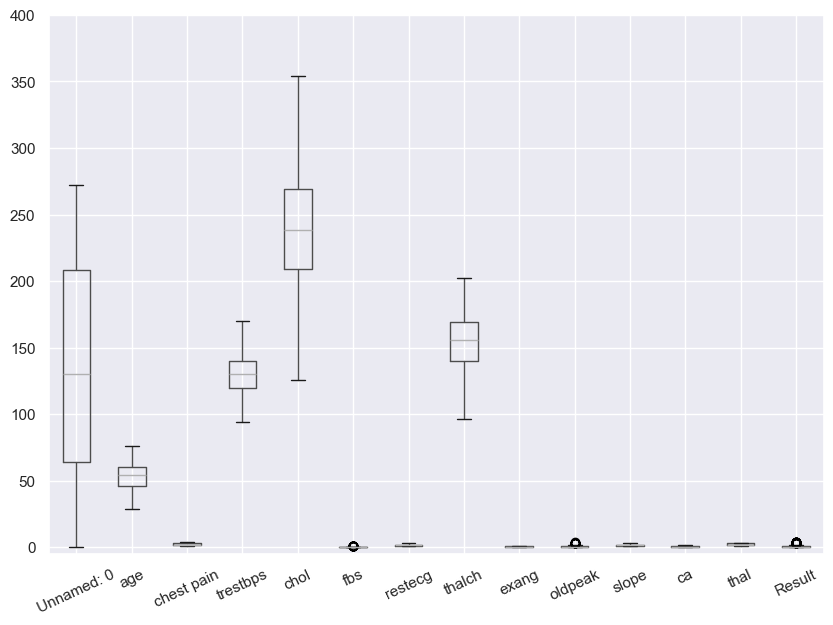

In [91]:
plt.figure(figsize=(10,7))
df.boxplot(rot=25)
plt.ylim(-5,400)

In [92]:
df

,Unnamed: 0,age,Gender,Country,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result
0,0,63,Male,Cleveland,1,145,233,1,1,150,0,2,3,0,1,0
1,2,67,Male,Cleveland,2,120,229,0,1,129,1,2,2,2,3,1
2,3,37,Male,Cleveland,3,130,250,0,2,187,0,3,3,0,2,0
3,4,41,Female,Cleveland,4,130,204,0,1,172,0,1,1,0,2,0
4,5,56,Male,Cleveland,4,120,236,0,2,178,0,0,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,268,68,Male,Switzerland,2,144,193,1,2,141,0,3,2,2,3,2
232,269,57,Male,Switzerland,2,130,131,0,2,115,1,1,2,1,3,3
233,270,57,Female,Switzerland,4,130,236,0,1,174,0,0,2,1,2,1
234,271,38,Male,Switzerland,3,138,175,0,2,173,0,0,1,0,2,0


# DATA MODELS (Regression)

In [93]:
df['bresult']=df["Result"].replace({2:1,3:1,4:1})
df

,Unnamed: 0,age,Gender,Country,chest pain,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Result,bresult
0,0,63,Male,Cleveland,1,145,233,1,1,150,0,2,3,0,1,0,0
1,2,67,Male,Cleveland,2,120,229,0,1,129,1,2,2,2,3,1,1
2,3,37,Male,Cleveland,3,130,250,0,2,187,0,3,3,0,2,0,0
3,4,41,Female,Cleveland,4,130,204,0,1,172,0,1,1,0,2,0,0
4,5,56,Male,Cleveland,4,120,236,0,2,178,0,0,1,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,268,68,Male,Switzerland,2,144,193,1,2,141,0,3,2,2,3,2,1
232,269,57,Male,Switzerland,2,130,131,0,2,115,1,1,2,1,3,3,1
233,270,57,Female,Switzerland,4,130,236,0,1,174,0,0,2,1,2,1,1
234,271,38,Male,Switzerland,3,138,175,0,2,173,0,0,1,0,2,0,0


In [94]:
df.columns

Index(['Unnamed: 0', 'age', 'Gender', 'Country', 'chest pain', 'trestbps',
       'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca',
       'thal', 'Result', 'bresult'],
      dtype='object')

### Importing train_test_split from sklearn library 

In [95]:
from sklearn.model_selection import train_test_split    
x=df[["age","chest pain","trestbps","chol","restecg","thalch","exang","fbs","oldpeak","slope","ca","thal"]]
y=df["bresult"]
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state=0)

In [96]:
x_train.shape,y_train.shape

((188, 12), (188,))

### Importing models and metrics from sklearn library 

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import classification_report


# Logistic Regression
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train)

# Decision Tree
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)

# Random Forest
random_forest_model = RandomForestClassifier()
random_forest_model.fit(x_train, y_train)

# K-nearest Neighbors
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

### Predictions of the testing data

#### Logistic Regression

In [98]:
y_pred_logistic = logistic_model.predict(x_test)

#### Decision Tree

In [99]:
y_pred_decision_tree = decision_tree_model.predict(x_test)

#### Random Forest

In [100]:
y_pred_random_forest = random_forest_model.predict(x_test)

#### K-nearest Neighbors

In [101]:
y_pred_knn = knn_model.predict(x_test)

## Calculation 
Confusion Matrix , Accuracy , ROC AUC Score                                                                         

### There are four models to calculate Confusion Matrix , Accuracy , ROC AUC Score.                                                    

### Models are as follows :

###  Logistic Regression

In [102]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_pred_logistic)

In [103]:
print("Logistic Regression:")
print()
print("Confusion Matrix:")
print(cm_logistic)
print()
print("Accuracy:",accuracy_logistic)
print()
print("ROC AUC Score:",roc_auc_logistic)
print()
print (classification_report(y_test,y_pred_logistic))
print()

Logistic Regression:

Confusion Matrix:
[[28  4]
 [ 3 13]]

Accuracy: 0.8541666666666666

ROC AUC Score: 0.84375

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        32
           1       0.76      0.81      0.79        16

    accuracy                           0.85        48
   macro avg       0.83      0.84      0.84        48
weighted avg       0.86      0.85      0.86        48




### Random Forest

In [104]:
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
roc_auc_random_forest = roc_auc_score(y_test, y_pred_random_forest)

In [105]:
print("Random Forest:")
print()
print("Confusion Matrix:")
print(cm_random_forest)
print()
print("Accuracy:", accuracy_random_forest)
print()
print("ROC AUC Score:", roc_auc_random_forest)
print()
print (classification_report(y_test,y_pred_random_forest))
print()

Random Forest:

Confusion Matrix:
[[28  4]
 [ 4 12]]

Accuracy: 0.8333333333333334

ROC AUC Score: 0.8125

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        32
           1       0.75      0.75      0.75        16

    accuracy                           0.83        48
   macro avg       0.81      0.81      0.81        48
weighted avg       0.83      0.83      0.83        48




###  Decision Tree

In [106]:
cm_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
roc_auc_decision_tree = roc_auc_score(y_test, y_pred_decision_tree)

In [107]:
print("Decision Tree:")
print()
print("Confusion Matrix:")
print(cm_decision_tree) 
print()
print("Accuracy:", accuracy_decision_tree)
print()
print("ROC AUC Score:", roc_auc_decision_tree)
print()
print (classification_report(y_test,y_pred_decision_tree))
print()

Decision Tree:

Confusion Matrix:
[[28  4]
 [ 7  9]]

Accuracy: 0.7708333333333334

ROC AUC Score: 0.71875

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.69      0.56      0.62        16

    accuracy                           0.77        48
   macro avg       0.75      0.72      0.73        48
weighted avg       0.76      0.77      0.76        48




### K-nearest Neighbors

In [108]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_knn)

In [109]:
print("K-nearest Neighbors:")
print()
print("Confusion Matrix:")
print(cm_knn)
print()
print("Accuracy:", accuracy_knn)
print()
print("ROC AUC Score:", roc_auc_knn)
print()
print (classification_report(y_test,y_pred_knn))
print()

K-nearest Neighbors:

Confusion Matrix:
[[26  6]
 [ 7  9]]

Accuracy: 0.7291666666666666

ROC AUC Score: 0.6875

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        32
           1       0.60      0.56      0.58        16

    accuracy                           0.73        48
   macro avg       0.69      0.69      0.69        48
weighted avg       0.73      0.73      0.73        48




In [110]:
import pickle

# Save model
with open("hd_model.pkl", "wb") as file:
    pickle.dump(random_forest_model, file)

print("✅ Random Forest model saved successfully as 'heart_disease_rf_model.pkl'")


✅ Random Forest model saved successfully as 'heart_disease_rf_model.pkl'
